# Notebook 3 — Predicción Conforme (Conformal Prediction)
### Tuberculosis bovina — cuantificación honesta de incertidumbre

La predicción conforme produce **conjuntos** (clasificación) o **intervalos** (regresión)
con **cobertura marginal garantizada** bajo intercambiabilidad, sin asumir un modelo
correcto. Es la herramienta adecuada cuando, como aquí, la discriminación es débil: en
lugar de un punto engañoso, devuelve la **incertidumbre real**.

> **Advertencia de intercambiabilidad.** Con solo **4 explotaciones**, los datos **no son
> intercambiables** entre granjas (clustering). La cobertura *marginal* sigue siendo válida
> dentro del cohorte, pero la cobertura *condicional por granja* y la extrapolación a granjas
> nuevas **no** están garantizadas. Lo evaluamos empíricamente.
> *(Refs.: Molnar, Introduction to Conformal Prediction with Python, 2023; Angelopoulos,
> Barber & Bates, Theoretical Foundations of Conformal Prediction, 2026 — cap. no-intercambiabilidad).*


## 1. Setup

In [1]:
# !pip install -q mapie scikit-learn xgboost matplotlib
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import tb_utils as tb
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
import xgboost as xgb
from mapie.classification import SplitConformalClassifier, CrossConformalClassifier
from mapie.regression import CrossConformalRegressor
PALETTE=tb.set_plot_style(); tb.set_seeds(tb.SEED)

import os
DATA = next((p for p in ["BD.csv","/mnt/project/BD.csv","data/BD.csv"] if os.path.exists(p)), "BD.csv")
df = tb.clean(tb.load_raw(DATA))
print("Datos:", df.shape)

Datos: (106, 19)


## 2. Clasificación conforme — Lesiones_TB (binaria)

Usamos **CV/Cross-conformal** (MAPIE 1.x), que aprovecha *toda* la muestra para calibrar —
preferible a *split* con *n* pequeño. Para *targets binarios* MAPIE admite el score **LAC**.
Evaluamos cobertura y tamaño de conjunto en una rejilla de niveles 1−α.


In [2]:
d = tb.target_subset(df, "Lesiones_TB")
X = d[tb.MODEL_FEATURES]; y = d["Lesiones_TB"].astype(int).values; g = d[tb.GROUP_COL].values

def base_clf():
    return Pipeline([("prep", tb.make_preprocessor()),
                     ("clf", LogisticRegression(C=0.3, class_weight="balanced",
                              solver="liblinear", max_iter=4000, random_state=tb.SEED))])

levels = [0.7, 0.8, 0.9]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=tb.SEED)
cc = CrossConformalClassifier(estimator=base_clf(), confidence_level=levels,
                              conformity_score="lac", cv=cv, random_state=tb.SEED)
cc.fit_conformalize(X, y)
_, ysets = cc.predict_set(X); ysets = np.asarray(ysets)   # (n, n_classes, n_levels)
rows=[]
for li,lv in enumerate(levels):
    s = ysets[:,:,li]
    rows.append(dict(nivel=lv, cobertura=s[np.arange(len(y)),y].mean(),
                     tam_medio=s.sum(1).mean(), pct_ambas=np.mean(s.sum(1)==2),
                     pct_vacio=np.mean(s.sum(1)==0)))
cov_tab = pd.DataFrame(rows)
print("Lesiones_TB — LAC (CV-conformal):")
print(cov_tab.round(3).to_string(index=False))
print("\n→ Para alcanzar la cobertura objetivo, los conjuntos contienen 'ambas clases' la")
print("  mayor parte del tiempo: el modelo rara vez excluye con confianza una clase.")

Lesiones_TB — LAC (CV-conformal):
 nivel  cobertura  tam_medio  pct_ambas  pct_vacio
   0.7      0.849      1.557      0.557        0.0
   0.8      0.915      1.726      0.726        0.0
   0.9      0.972      1.915      0.915        0.0

→ Para alcanzar la cobertura objetivo, los conjuntos contienen 'ambas clases' la
  mayor parte del tiempo: el modelo rara vez excluye con confianza una clase.


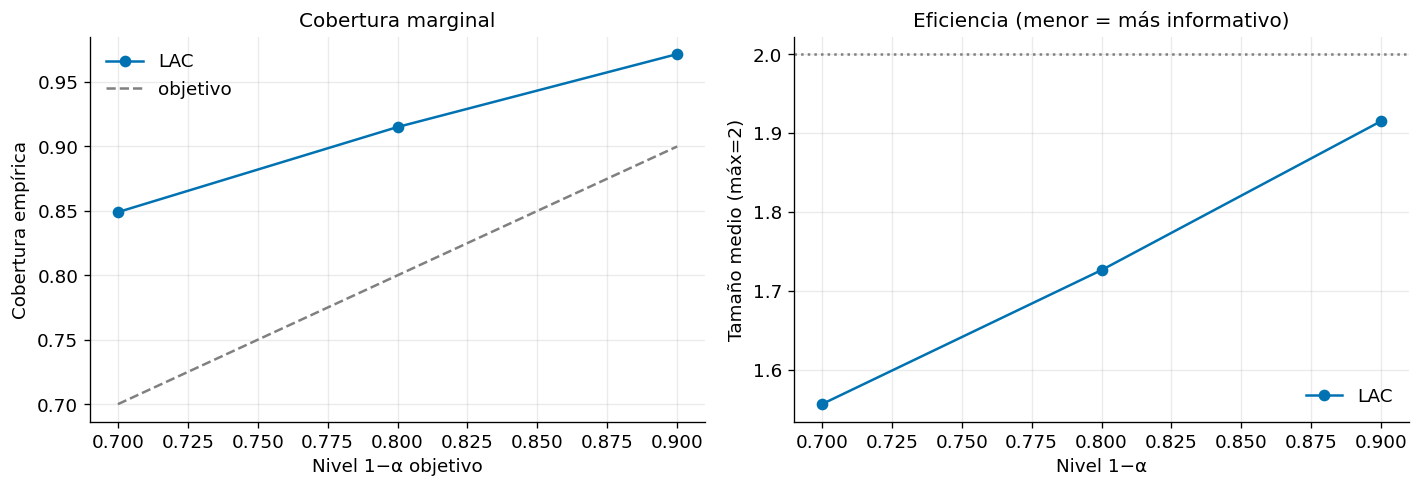

In [3]:
# Curva cobertura vs eficiencia (tamaño de conjunto)
fig, ax = plt.subplots(1,2, figsize=(12,4.2))
ax[0].plot(cov_tab.nivel, cov_tab.cobertura, "o-", color=PALETTE[0], label="LAC")
ax[0].plot(levels, levels, "--", color="grey", label="objetivo")
ax[1].plot(cov_tab.nivel, cov_tab.tam_medio, "o-", color=PALETTE[0], label="LAC")
ax[0].set_xlabel("Nivel 1−α objetivo"); ax[0].set_ylabel("Cobertura empírica"); ax[0].set_title("Cobertura marginal"); ax[0].legend()
ax[1].axhline(2, ls=":", color="grey"); ax[1].set_xlabel("Nivel 1−α"); ax[1].set_ylabel("Tamaño medio (máx=2)")
ax[1].set_title("Eficiencia (menor = más informativo)"); ax[1].legend()
plt.tight_layout(); plt.savefig("figures/fig12_conformal_coverage.png"); plt.show()

### 2b. Conjuntos conformes multiclase — Score lesional {0,1,2,4,5}

Tratando el *score* como variable **nominal de 5 clases** ilustramos LAC vs **APS**
(*Adaptive Prediction Sets*), que ajusta el tamaño del conjunto a la dificultad de cada caso.


In [4]:
sc_classes = sorted(df["Score_lesional"].dropna().unique().astype(int))
Xs = df[tb.MODEL_FEATURES]; ys = df["Score_lesional"].astype(int).values
clf_mc = Pipeline([("prep", tb.make_preprocessor()),
                   ("clf", xgb.XGBClassifier(n_estimators=120, max_depth=2, learning_rate=0.05,
                            reg_lambda=3.0, eval_metric="mlogloss", random_state=tb.SEED))])
# XGBoost requiere clases contiguas 0..K-1 -> recodificar
remap = {c:i for i,c in enumerate(sc_classes)}; inv={i:c for c,i in remap.items()}
ys_e = np.vectorize(remap.get)(ys)
mc_rows=[]
for score in ["lac","aps"]:
    cc_mc = CrossConformalClassifier(estimator=clf_mc, confidence_level=0.8,
                                     conformity_score=score,
                                     cv=StratifiedKFold(5,shuffle=True,random_state=tb.SEED),
                                     random_state=tb.SEED)
    cc_mc.fit_conformalize(Xs, ys_e)
    _, st = cc_mc.predict_set(Xs); st=np.asarray(st)[:,:,0]
    cov = st[np.arange(len(ys_e)), ys_e].mean()
    mc_rows.append(dict(score=score.upper(), cobertura=cov, tam_medio=st.sum(1).mean(),
                        n_clases=len(sc_classes)))
print("Score lesional multiclase (objetivo 0.80):")
print(pd.DataFrame(mc_rows).round(3).to_string(index=False))
print("→ APS suele dar cobertura condicional por clase más equilibrada a costa de conjuntos algo mayores.")

Score lesional multiclase (objetivo 0.80):
score  cobertura  tam_medio  n_clases
  LAC        1.0      3.491         5
  APS        1.0      4.274         5
→ APS suele dar cobertura condicional por clase más equilibrada a costa de conjuntos algo mayores.


## 3. Cobertura condicional por subgrupos clínicos

In [5]:
# Re-calcula conjuntos LAC al 80% y evalúa cobertura por raza, sexo y GRANJA
cc = CrossConformalClassifier(estimator=base_clf(), confidence_level=0.8,
                              conformity_score="lac",
                              cv=StratifiedKFold(5,shuffle=True,random_state=tb.SEED),
                              random_state=tb.SEED)
cc.fit_conformalize(X, y)
_, s80 = cc.predict_set(X); s80=np.asarray(s80)[:,:,0]
covered = s80[np.arange(len(y)), y]; setsize = s80.sum(1)

cond=[]
for var in ["RAZA2","SEXO",tb.GROUP_COL]:
    for lvl,grp in d.groupby(var):
        m = d.index.get_indexer(grp.index)
        cond.append(dict(subgrupo=f"{var}={lvl}", n=len(grp),
                         cobertura=covered[m].mean(), tam_medio=setsize[m].mean()))
cond_tab=pd.DataFrame(cond)
print("Cobertura condicional (objetivo 0.80):")
print(cond_tab.round(3).to_string(index=False))
print("\n→ Desviaciones por granja ilustran la NO-intercambiabilidad: la garantía marginal")
print("  no se traslada uniformemente a cada explotación.")

Cobertura condicional (objetivo 0.80):
        subgrupo  n  cobertura  tam_medio
RAZA2=Alentejana 20      0.850      1.700
   RAZA2=Cruzado 85      0.929      1.741
      RAZA2=Otra  1      1.000      1.000
          SEXO=F 98      0.918      1.724
          SEXO=M  8      0.875      1.750
      Expl=VA32D 21      0.952      1.857
      Expl=VC30D 55      0.927      1.727
      Expl=VC94C 16      0.812      1.562
      Expl=WZ72B 14      0.929      1.714

→ Desviaciones por granja ilustran la NO-intercambiabilidad: la garantía marginal
  no se traslada uniformemente a cada explotación.


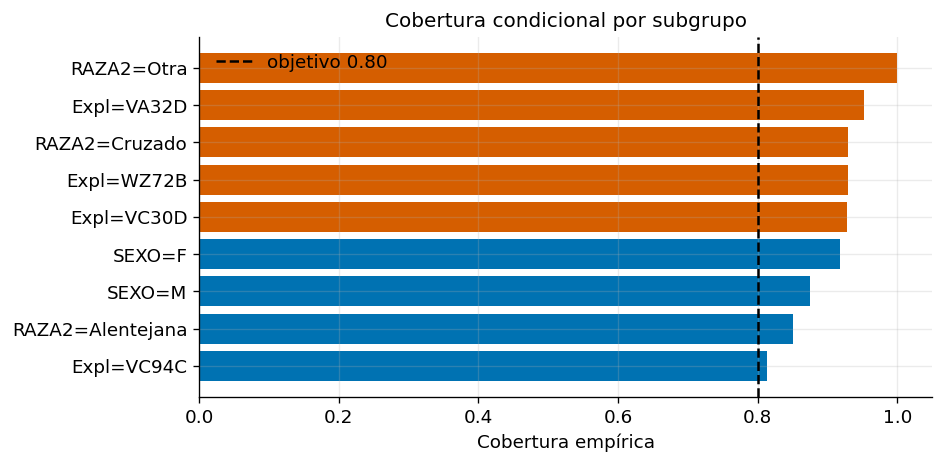

In [6]:
fig, ax = plt.subplots(figsize=(8,4))
c=cond_tab.sort_values("cobertura")
colors=[PALETTE[1] if abs(v-0.8)>0.12 else PALETTE[0] for v in c.cobertura]
ax.barh(c.subgrupo, c.cobertura, color=colors)
ax.axvline(0.8, ls="--", color="k", label="objetivo 0.80")
ax.set_xlabel("Cobertura empírica"); ax.set_title("Cobertura condicional por subgrupo")
ax.legend(); plt.tight_layout(); plt.savefig("figures/fig13_conditional_coverage.png"); plt.show()

## 4. Intervalos conformes — IDTC (recuento) y Score lesional (ordinal)

In [7]:
def base_reg():
    return Pipeline([("prep", tb.make_preprocessor()),
                     ("clf", xgb.XGBRegressor(n_estimators=150, max_depth=2, learning_rate=0.05,
                              subsample=0.8, reg_lambda=3.0, random_state=tb.SEED))])

reg_rows=[]
for target in ["IDTC","Score_lesional"]:
    s=tb.target_subset(df,target); Xs=s[tb.MODEL_FEATURES]; ys=s[target].values.astype(float)
    for lvl in [0.7,0.8,0.9]:
        cr=CrossConformalRegressor(estimator=base_reg(), confidence_level=lvl, cv=5)
        cr.fit_conformalize(Xs,ys)
        _, yint=cr.predict_interval(Xs); yint=np.asarray(yint)[:,:,0]
        cov=((ys>=yint[:,0])&(ys<=yint[:,1])).mean(); width=(yint[:,1]-yint[:,0]).mean()
        reg_rows.append(dict(target=target, nivel=lvl, cobertura=cov, ancho_medio=width,
                             rango=ys.max()-ys.min()))
reg_tab=pd.DataFrame(reg_rows)
print(reg_tab.round(2).to_string(index=False))
print("\n→ El ancho de los intervalos cubre una fracción grande del rango → predicción")
print("  individual poco informativa (coherente con Spearman fuera de granja ≈ 0).")

        target  nivel  cobertura  ancho_medio  rango
          IDTC    0.7       0.90        13.95   32.0
          IDTC    0.8       0.97        17.97   32.0
          IDTC    0.9       0.99        24.95   32.0
Score_lesional    0.7       0.92         4.13    5.0
Score_lesional    0.8       0.99         5.32    5.0
Score_lesional    0.9       0.99         6.97    5.0

→ El ancho de los intervalos cubre una fracción grande del rango → predicción
  individual poco informativa (coherente con Spearman fuera de granja ≈ 0).


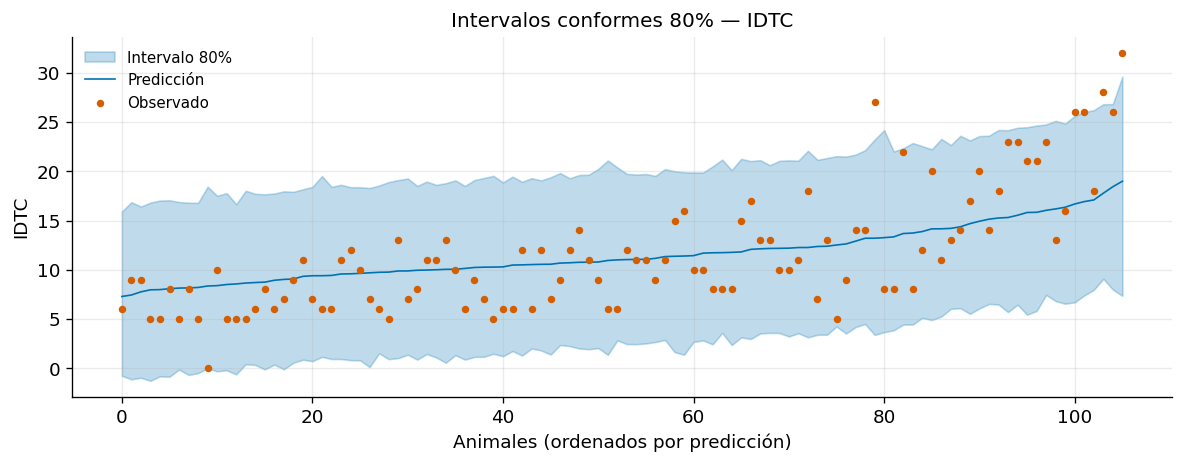

In [8]:
# Visualización: intervalos al 80% para IDTC (ordenados por predicción)
s=df; Xs=s[tb.MODEL_FEATURES]; ys=s["IDTC"].values.astype(float)
cr=CrossConformalRegressor(estimator=base_reg(), confidence_level=0.8, cv=5)
cr.fit_conformalize(Xs,ys); yp,yint=cr.predict_interval(Xs)
yp=np.asarray(yp).ravel(); yint=np.asarray(yint)[:,:,0]
o=np.argsort(yp)
fig,ax=plt.subplots(figsize=(10,4))
ax.fill_between(range(len(o)), yint[o,0], yint[o,1], alpha=.25, color=PALETTE[0], label="Intervalo 80%")
ax.plot(range(len(o)), yp[o], color=PALETTE[0], lw=1, label="Predicción")
ax.scatter(range(len(o)), ys[o], s=12, color=PALETTE[1], label="Observado", zorder=3)
ax.set_xlabel("Animales (ordenados por predicción)"); ax.set_ylabel("IDTC")
ax.set_title("Intervalos conformes 80% — IDTC"); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig("figures/fig14_conformal_intervals.png"); plt.show()

## 5. Comparación con *split-conformal* y robustez en *n* pequeño

In [9]:
# Split-conformal (prefit) repetido para ver la variabilidad de la cobertura con n pequeño
covs=[]
for seed in range(50):
    Xtr,Xrest,ytr,yrest=train_test_split(X,y,test_size=0.5,stratify=y,random_state=seed)
    Xcal,Xte,ycal,yte=train_test_split(Xrest,yrest,test_size=0.5,stratify=yrest,random_state=seed)
    clf=base_clf().fit(Xtr,ytr)
    sc=SplitConformalClassifier(estimator=clf,confidence_level=0.8,conformity_score="lac",prefit=True)
    sc.conformalize(Xcal,ycal)
    _,st=sc.predict_set(Xte); st=np.asarray(st)[:,:,0]
    covs.append(st[np.arange(len(yte)),yte].mean())
print(f"Split-conformal 80% (50 repeticiones): cobertura media={np.mean(covs):.3f} ± {np.std(covs):.3f}")
print(f"  rango [{np.min(covs):.2f}, {np.max(covs):.2f}] → alta variabilidad por la calibración pequeña.")
print("  Por ello se prefiere CV/Cross-conformal aquí.")

Split-conformal 80% (50 repeticiones): cobertura media=0.812 ± 0.099
  rango [0.59, 1.00] → alta variabilidad por la calibración pequeña.
  Por ello se prefiere CV/Cross-conformal aquí.


## 6. Utilidad clínica e interpretación

- A niveles de confianza clínicamente razonables (≥80 %), los **conjuntos** para *lesión* y
  *patrón* contienen casi siempre **ambas clases**, y los **intervalos** para *IDTC*/*score*
  cubren gran parte del rango. Es decir, el modelo, **honestamente**, "no sabe".
- Esto es **información valiosa**: descarta el uso de estos biomarcadores para **triaje
  individual** de gravedad de TB y orienta a no sobre-interpretar asociaciones en muestra.
- La **no-intercambiabilidad entre granjas** implica que cualquier despliegue debería
  recalibrarse por explotación y validarse prospectivamente en granjas nuevas.
